In [1]:
from pyspark.sql import SparkSession

# Configuramos Spark para que use 3 Gigabytes de la RAM que le dimos al contenedor
spark = SparkSession.builder \
    .appName("ModeloCebada") \
    .config("spark.driver.memory", "6g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

In [2]:
from pyspark.sql import SparkSession

# Iniciar la sesión de Spark
spark = SparkSession.builder \
    .appName("ProyectoCebadaSpark") \
    .getOrCreate()

print("¡Spark está listo y activo! 🌾")
print(f"Versión de Spark: {spark.version}")

¡Spark está listo y activo! 🌾
Versión de Spark: 3.5.0


In [7]:
##LIMPIEZA MINERIA 

In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lower

# 1. Inicializar la sesión de Spark
spark = SparkSession.builder \
    .appName("FiltradoCebada") \
    .getOrCreate()

# 2. Cargar el archivo CSV original
# Reemplaza la ruta por la ubicación de tu archivo original
path_original = "datos_agricolas_clean.csv"

df = spark.read.csv(path_original, header=True, inferSchema=True)

df_cebada = df.filter(lower(col("Nomcultivo")).contains("cebada"))


# 4. Mostrar una vista previa de los datos filtrados
df_cebada.show(5)


path_salida = "datos_cebada_spark"
df_cebada.coalesce(1).write.csv(path_salida, header=True, mode="overwrite")

print(f"¡Listo! Los datos filtrados se guardaron en la carpeta: {path_salida}")

+----+--------+---------------+-----+--------+-------+--------+-----------+------------------+-------+------------------+-----------+------------+--------------+---------+---------+--------------------+--------+---------+-----------+-----------------+-----------+----------------+---------------+
|Anio|Idestado|      Nomestado|Idddr|  Nomddr|Idcader|Nomcader|Idmunicipio|      Nommunicipio|Idciclo|Nomcicloproductivo|Idmodalidad|Nommodalidad|Idunidadmedida|Nomunidad|Idcultivo|          Nomcultivo|Sembrada|Cosechada|Siniestrada|Volumenproduccion|Rendimiento|Preciomediorural|Valorproduccion|
+----+--------+---------------+-----+--------+-------+--------+-----------+------------------+-------+------------------+-----------+------------+--------------+---------+---------+--------------------+--------+---------+-----------+-----------------+-----------+----------------+---------------+
|2024|       2|Baja California|    2|Ensenada|      1| Tijuana|          4|           Tijuana|      1|    Oto

In [ ]:
##GRANDES VOLUMENES

In [7]:
from pyspark.sql.functions import col, count, desc, upper, trim
from pyspark.sql import SparkSession

# 1. Asegurar la sesión de Spark con configuración optimizada para tu máquina
spark = SparkSession.builder \
    .appName("CebadaAnalysis") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

print("--- Nueva base ---")
# Leemos directamente la carpeta que generamos en el paso anterior
df_cebada_sp = spark.read.csv("cebada_base_unida.csv", header=True, inferSchema=True)

print("MAPEO DE FLUJO (QUIEN EXPORTA Y QUIEN RECIBE)")

# 3. Estandarizamos el Estado a mayúsculas y sin espacios antes de agrupar 
# Usamos 'Estado' porque es la columna que conservamos limpia en el join
df_cebada_preparado = df_cebada_sp \
    .withColumn("Estado_Limpio", upper(trim(col("Estado")))) \
    .withColumn("Idmunicipio_Limpio", upper(trim(col("Idmunicipio").cast("string"))))

# 4. Agrupar por las nuevas columnas estandarizadas de la base nueva
df_flujo = df_cebada_preparado.groupBy("Idmunicipio_Limpio", "Estado_Limpio") \
    .agg(count("*").alias("Total_Envios")) \
    .orderBy(desc("Total_Envios"))

print("\nPrincipales rutas de distribucion detectadas (Origen / Destino):")
df_flujo.show(20, truncate=False)

# 5. Guardar el DataFrame ordenado en tu variable global
df_flujo_logistico = df_flujo
print("\n[OK] Flujo calculado con la nueva base y guardado en 'df_flujo_logistico'")

print("\n--- GUARDANDO EL RESULTADO EN TU CARPETA DE TRABAJO ---")
# Guardamos este mapa de flujo logístico en una nueva carpetita para que lo tengas a la mano
df_flujo_logistico.write \
    .mode("overwrite") \
    .option("header", "true") \
    .csv("resultado_flujo_logistico")

print("¡Listo! El análisis ya terminó usando tus datos reales unificados.")

--- Nueva base ---
MAPEO DE FLUJO (QUIEN EXPORTA Y QUIEN RECIBE)

Principales rutas de distribucion detectadas (Origen / Destino):
+------------------+-------------+------------+
|Idmunicipio_Limpio|Estado_Limpio|Total_Envios|
+------------------+-------------+------------+
|89                |PUEBLA       |219604      |
|75                |PUEBLA       |164703      |
|-41               |PUEBLA       |164703      |
|57                |PUEBLA       |164703      |
|32                |PUEBLA       |164703      |
|82                |CHIHUAHUA    |154167      |
|31                |CHIHUAHUA    |154167      |
|122               |CHIHUAHUA    |154167      |
|68                |CHIHUAHUA    |154167      |
|55                |PUEBLA       |109802      |
|20                |PUEBLA       |109802      |
|48                |PUEBLA       |109802      |
|87                |PUEBLA       |109802      |
|68                |PUEBLA       |109802      |
|85                |PUEBLA       |109802      |
|94  

In [8]:
from pyspark.sql import SparkSession

# 1. Asegurar la sesión de Spark optimizada
spark = SparkSession.builder \
    .appName("AnalizaBaseUnificadaSpark") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

print("\n" + "="*50)
print(" ANALIZANDO")
print("="*50)

try:
    # 2. Cargar la carpeta de la base unificada real usando Spark
    df_unificado = spark.read.csv("cebada_base_unida.csv", header=True, inferSchema=True)
    
    # 3. Obtener e imprimir las columnas detectadas
    columnas = df_unificado.columns
    print("\n nueva base")
    print(columnas)
    
    # 4. Contar el total de registros usando el poder de Spark
    total_registros = df_unificado.count()
    print(f"\n Total de registros combinados en la base: {total_registros}")
    
    # 5. Mostrar la muestra de los datos de forma limpia en pantalla
    print("\n Así luce una muestra de tus datos reales unificados:")
    # Seleccionamos las primeras columnas disponibles para armar tu reporte dinámico
    columnas_a_mostrar = [c for c in ["Cliente", "Nombre", "Estado", "Idmunicipio"] if c in columnas]
    
    if columnas_a_mostrar:
        df_unificado.select(columnas_a_mostrar).show(5, truncate=False)
    else:
        # Si por alguna razón cambiaron los nombres, muestra las primeras 4 columnas que existan
        df_unificado.select(columnas[:4]).show(5, truncate=False)

    print("[OK] Análisis con Spark terminado con éxito.")

except Exception as e:
    print("\n[ERROR OCURRIDO EN SPARK]:", e)


 ANALIZANDO

 nueva base
['Idestado', 'Idddr', 'Nomcader', 'Idmunicipio', 'Nommunicipio', 'Idmodalidad', 'Idunidadmedida', 'Nomunidad', 'Idcultivo', 'Nomcultivo', 'Sembrada', 'Cosechada', 'Siniestrada', 'Volumenproduccion', 'Rendimiento', 'Preciomediorural', 'Valorproduccion', 'ID_Lote', 'Estado', 'Sistema_Cultivo', 'Superficie_Ha', 'Rendimiento_Ton_Ha', 'Humedad_Recepcion_%', 'Proteina_Total_ss_%', 'Calibre_>2.5mm_%', 'Energia_Germinacion_%', 'Indice_Kolbach_%', 'Poder_Diastasico_WK', 'Beta_Glucanos_mg_l', 'Extracto_Fina_db_%', 'Precio_Venta_Ton_MXN', 'Produccion_Total_Ton', 'Valor_Produccion_kMXN', 'INEGI. Censo Agropecuario 2022', 'Cuadro ca2022_agr02', 'Mes_Cosecha', 'Anio', 'Fecha_Completa', 'Cliente', 'Nombre', 'DRV', 'UEN', 'SAG', 'z01', 'Estatus', 'Monto CM', 'Prom', 'Vol Feb', 'Gerencia General', 'Regional_ Modes', 'Gerente/Lider', 'pob_clave_entidad', 'pob_clave_municipio', 'pob_municipio', 'pob_longitud', 'pob_latitud', 'pob_poblacion']

 Total de registros combinados en la

In [9]:
from pyspark.sql.functions import col, upper, trim, count
from pyspark.sql import SparkSession

# 1. Asegurar la sesión de Spark optimizada
spark = SparkSession.builder \
    .appName("MercadoJustoSparkFijado") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

print("--- CARGANDO LA BASE UNIFICADA NUEVA EN SPARK ---")
# COMANDO PARA SUBIR LA BASE: Leemos la carpeta con todos los datos cruzados
df_unificado = spark.read.csv("cebada_base_unida.csv", header=True, inferSchema=True)

print("\ncrece entre modeloramas y productores")

# 2. Filtrar los modeloramas activos usando la columna de tu base unificada
df_modelos_activos = df_unificado.filter(upper(trim(col("Estatus"))) == "ACTIVO") \
    .withColumn("Estado_Cebada", upper(trim(col("Estado"))))

# 3. Calcular cuántos modeloramas receptores hay por cada estado en memoria
df_conteo_modelos = df_modelos_activos.groupBy("Estado_Cebada") \
    .agg(count("*").alias("total_modeloramas_receptores"))

# 4. Cruzar los conteos y agrupar por Municipio para ver el volumen de envíos
df_mercado_justo = df_modelos_activos \
    .join(df_conteo_modelos, "Estado_Cebada", "inner") \
    .groupBy("Idmunicipio", "Estado_Cebada", "total_modeloramas_receptores") \
    .agg(count("*").alias("Volumen_Envios_Cebada")) \
    .orderBy("Estado_Cebada", col("Volumen_Envios_Cebada").desc())

print("el municipio abastece al modelorama:")
# Muestra la tabla final en pantalla de inmediato
df_mercado_justo.show(20, truncate=False)

--- CARGANDO LA BASE UNIFICADA NUEVA EN SPARK ---

crece entre modeloramas y productores
el municipio abastece al modelorama:
+-----------+-------------+----------------------------+---------------------+
|Idmunicipio|Estado_Cebada|total_modeloramas_receptores|Volumen_Envios_Cebada|
+-----------+-------------+----------------------------+---------------------+
|82         |CHIHUAHUA    |3250170                     |77385                |
|31         |CHIHUAHUA    |3250170                     |77385                |
|122        |CHIHUAHUA    |3250170                     |77385                |
|68         |CHIHUAHUA    |3250170                     |77385                |
|-11        |CHIHUAHUA    |3250170                     |51590                |
|127        |CHIHUAHUA    |3250170                     |51590                |
|1          |CHIHUAHUA    |3250170                     |51590                |
|63         |CHIHUAHUA    |3250170                     |51590                |
|-28 

In [ ]:
##MODELOS ESTOCASTICOS

--- CARGANDO LA BASE UNIFICADA NUEVA EN SPARK ---
--- Limpiando y preparando tipos de datos con Spark ---
--- Convirtiendo a Pandas para el modelo predictivo ARIMA ---
--- Generando gráfica del comportamiento histórico y pronóstico ---


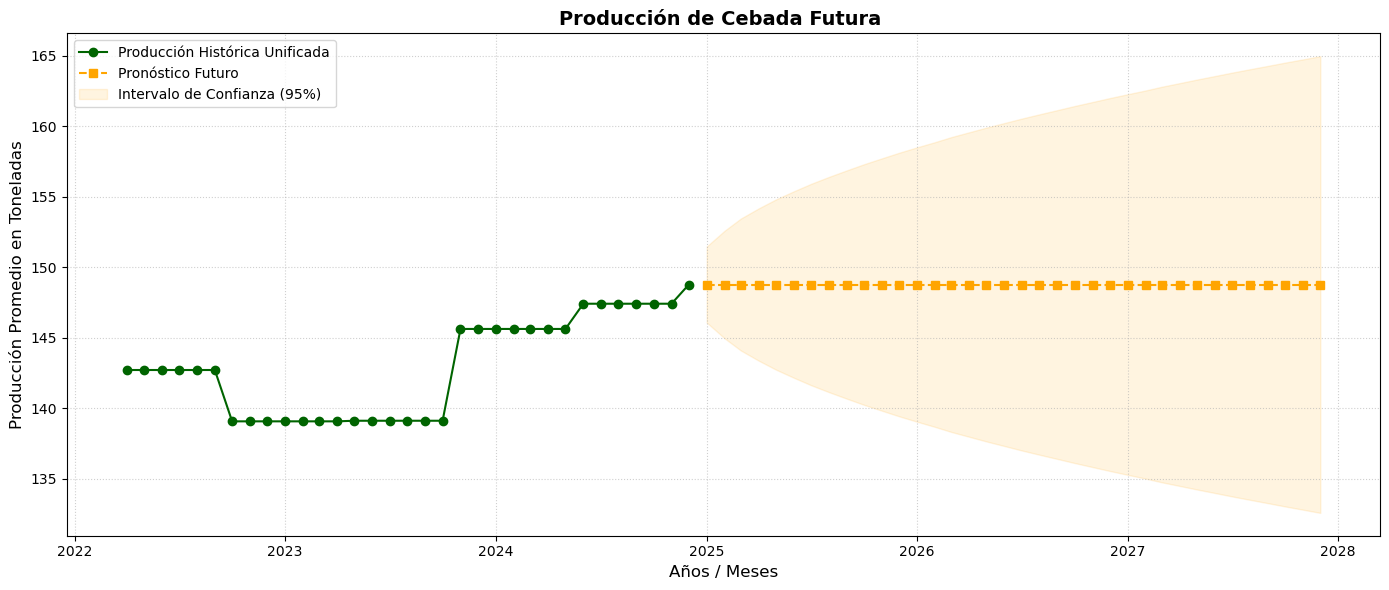

 REPORTES DE PRODUCCIÓN APROXIMADA AL 2027:
El mes con mayor produccion: January 2027
Con una aproximacion de: 148.77 Toneladas promedio.


In [6]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# 1. Asegurar la sesión de Spark optimizada para tu máquina
spark = SparkSession.builder \
    .appName("Pronostico_cebada_ARIMA") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

print("--- CARGANDO LA BASE UNIFICADA NUEVA EN SPARK ---")
# COMANDO PARA SUBIR LA BASE: Leemos tu carpeta con los datos cruzados reales
archivo_csv = "cebada_base_unida.csv"
df_spark = spark.read.csv(archivo_csv, header=True, inferSchema=True)

variable_produccion = 'Produccion_Total_Ton'

print("--- Limpiando y preparando tipos de datos con Spark ---")
# Filtramos nulos y aseguramos formato de fecha y dobles
df_clean = df_spark \
    .withColumn('Fecha_Completa', F.to_date(F.col('Fecha_Completa'))) \
    .withColumn(variable_produccion, F.col(variable_produccion).cast(DoubleType())) \
    .filter(F.col('Fecha_Completa').isNotNull() & F.col(variable_produccion).isNotNull()) \
    .filter(F.col(variable_produccion) >= 0)

# Agrupamos por fecha para obtener la serie de producción promedio
serie_produccion_spark = df_clean.groupby('Fecha_Completa') \
    .agg(F.mean(variable_produccion).alias(variable_produccion)) \
    .orderBy('Fecha_Completa')

print("--- Convirtiendo a Pandas para el modelo predictivo ARIMA ---")
serie_produccion = serie_produccion_spark.toPandas()

# Configuración del índice de tiempo en Pandas
serie_produccion['Fecha_Completa'] = pd.to_datetime(serie_produccion['Fecha_Completa'])
serie_produccion = serie_produccion.sort_values('Fecha_Completa').set_index('Fecha_Completa')
serie_produccion = serie_produccion.asfreq('MS', method='ffill')

modelo = ARIMA(
    serie_produccion[variable_produccion], 
    order=(2, 1, 2),              # Componente no estacional
    seasonal_order=(1, 1, 1, 12)  # ¡AQUÍ ESTÁ LA CLAVE! El 12 indica estacionalidad mensual
)

# Pronóstico a 36 meses (3 años: 2025 - 2027)
pasos_futuros = 36
prediccion = resultado.get_forecast(steps=pasos_futuros)
produccion_futura = prediccion.predicted_mean
intervalo_confianza = prediccion.summary_frame()

print("--- Generando gráfica del comportamiento histórico y pronóstico ---")
plt.figure(figsize=(14, 6))

# Gráfica de datos históricos unificados
plt.plot(serie_produccion.index, serie_produccion[variable_produccion],
         label='Producción Histórica Unificada', marker='o', color='darkgreen')

# Gráfica de la predicción futura
plt.plot(produccion_futura.index, produccion_futura,
         label='Pronóstico Futuro', color='orange', linestyle='--', marker='s')

# Sombreado del intervalo de confianza
plt.fill_between(
    intervalo_confianza.index,
    intervalo_confianza['mean_ci_lower'],
    intervalo_confianza['mean_ci_upper'],
    color='orange',
    alpha=0.12,
    label='Intervalo de Confianza (95%)'
)

plt.title('Producción de Cebada Futura ', fontsize=14, fontweight='bold')
plt.xlabel('Años / Meses', fontsize=12)
plt.ylabel('Producción Promedio en Toneladas', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Extraer el pico de producción del último año estimado
prediccion_2027 = produccion_futura['2027']
mes_max_2027 = prediccion_2027.idxmax().strftime('%B %Y')
produccion_max_2027 = prediccion_2027.max()

print(" REPORTES DE PRODUCCIÓN APROXIMADA AL 2027:")

print(f"El mes con mayor produccion: {mes_max_2027}")
print(f"Con una aproximacion de: {produccion_max_2027:,.2f} Toneladas promedio.")

--- CARGANDO LA BASE UNIFICADA NUEVA EN SPARK ---
--- Procesando y limpiando variables de rendimiento con Spark ---
--- Convirtiendo a Pandas para el análisis de distribución estadística ---
--- REGENERANDO EL ESTILO VISUAL DE LOS SUBPLOTS ---


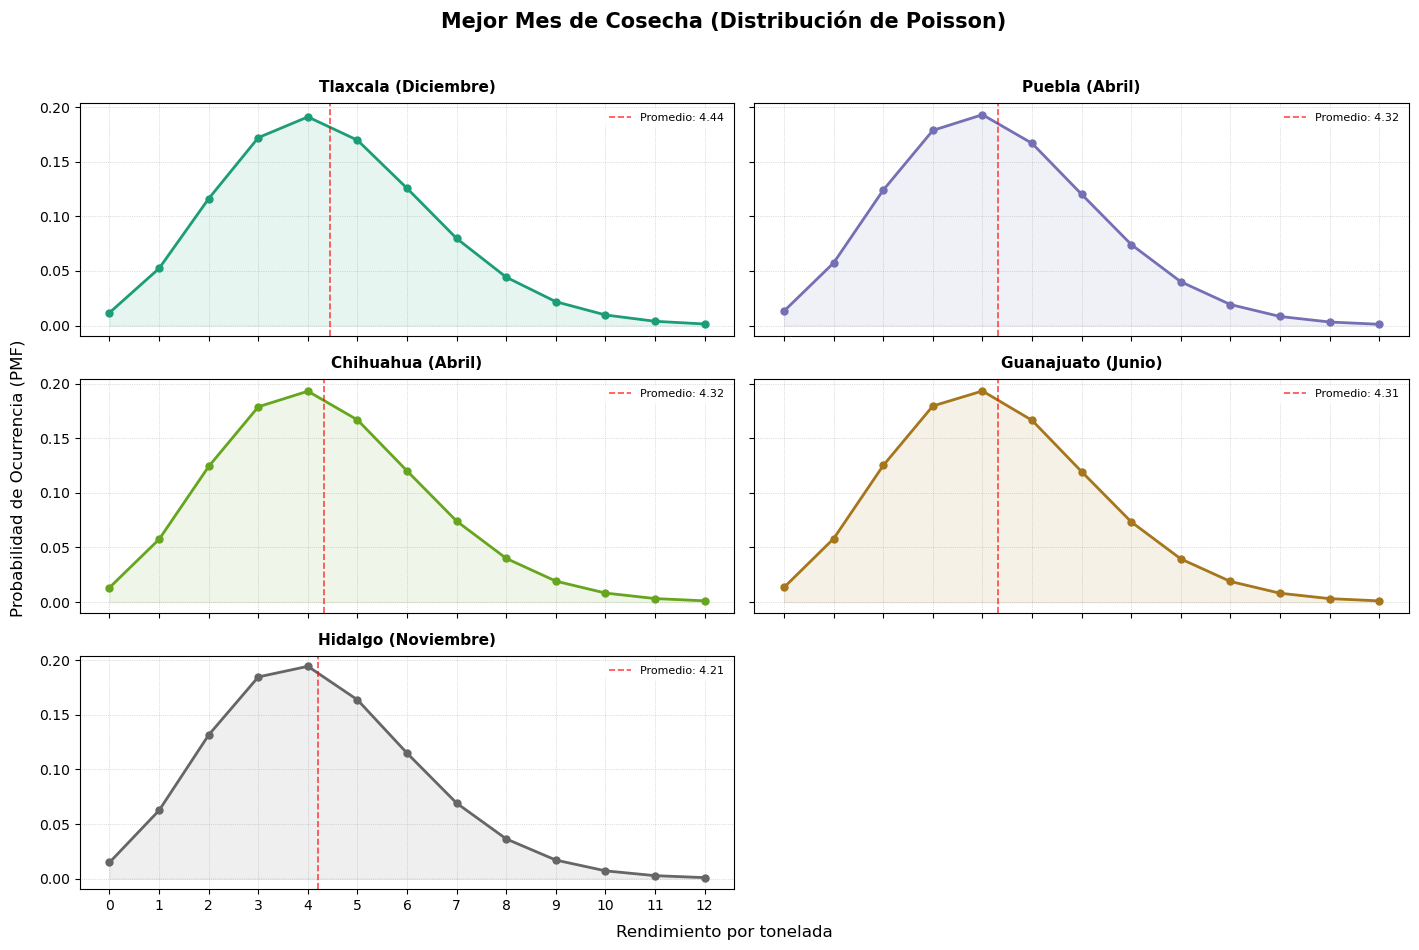

In [12]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# 1. Asegurar la sesión de Spark optimizada
spark = SparkSession.builder \
    .appName("Analisis_Poisson_Clima") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

print("--- CARGANDO LA BASE UNIFICADA NUEVA EN SPARK ---")
# COMANDO PARA SUBIR LA BASE: Leemos la carpeta con todos tus datos cruzados reales
archivo_csv = "cebada_base_unida.csv"
df_spark = spark.read.csv(archivo_csv, header=True, inferSchema=True)

print("--- Procesando y limpiando variables de rendimiento con Spark ---")
# Aseguramos que las columnas numéricas no tengan problemas de tipos
df_clean = df_spark \
    .withColumn("Rendimiento_Ton_Ha", F.col("Rendimiento_Ton_Ha").cast(DoubleType())) \
    .withColumn("Precio_Venta_Ton_MXN", F.col("Precio_Venta_Ton_MXN").cast(DoubleType())) \
    .na.fill(0, ["Rendimiento_Ton_Ha", "Precio_Venta_Ton_MXN"])

# Agrupamos por Estado y Mes usando el motor de Spark
analisis_clima_spark = df_clean.groupby(["Estado", "Mes_Cosecha"]) \
    .agg(
        F.mean("Rendimiento_Ton_Ha").alias("Rendimiento_Prom_Ton_Ha"),
        F.mean("Precio_Venta_Ton_MXN").alias("Precio_Prom_MXN")
    )

print("--- Convirtiendo a Pandas para el análisis de distribución estadística ---")
analisis_clima = analisis_clima_spark.toPandas()

# Encontrar los mejores meses de rendimiento por cada Estado en Pandas
idx_mejores = analisis_clima.groupby("Estado")["Rendimiento_Prom_Ton_Ha"].idxmax()
mejores_temporadas_estados = analisis_clima.loc[idx_mejores].sort_values(
    by="Rendimiento_Prom_Ton_Ha", ascending=False
)

# Configuración de los recuadros de la gráfica (Subplots)
num_estados = len(mejores_temporadas_estados)
columnas = 2
filas = (num_estados + 1) // columnas

print("--- REGENERANDO EL ESTILO VISUAL DE LOS SUBPLOTS ---")
# Resetear la memoria de figuras de matplotlib y forzar estilo limpio
plt.clf()
plt.close('all')
plt.style.use('default')

fig, axes = plt.subplots(filas, columnas, figsize=(14, 3 * filas), sharex=True, sharey=True, dpi=100)
axes = axes.flatten() 

x_toneladas = np.arange(0, 13)  # Rango de rendimiento a evaluar (0 a 12 toneladas)
cmap = plt.colormaps["Dark2"].resampled(num_estados)

for i, (index, fila) in enumerate(mejores_temporadas_estados.iterrows()):
    ax = axes[i]
    estado = fila["Estado"]
    mes = fila["Mes_Cosecha"]
    lambda_rendimiento = fila["Rendimiento_Prom_Ton_Ha"]
    
    # Calcular las probabilidades de Poisson usando la media real (lambda)
    probabilidades = poisson.pmf(x_toneladas, mu=lambda_rendimiento)
    
    # 1. Graficar la curva con marcadores y la línea estilizada
    ax.plot(x_toneladas, probabilidades, 
            marker='o', 
            markersize=5, 
            linestyle='-', 
            color=cmap(i), 
            linewidth=2)
    
    # 2. Relleno sutil debajo de la curva
    ax.fill_between(x_toneladas, probabilidades, color=cmap(i), alpha=0.10)
    
    # 3. Línea vertical roja punteada para indicar el promedio exacto
    ax.axvline(x=lambda_rendimiento, color='red', linestyle='--', alpha=0.7, 
               linewidth=1.2, label=f'Promedio: {lambda_rendimiento:.2f}')
    
    # 4. Ajustes finos por cada recuadro (Grid sutil punteado gris)
    ax.set_title(f"{estado} ({mes})", fontsize=11, fontweight="bold", pad=8)
    ax.set_xticks(x_toneladas)
    ax.grid(True, linestyle=":", linewidth=0.5, color='gray', alpha=0.5)
    ax.legend(loc="upper right", fontsize=8, frameon=True, facecolor='white', edgecolor='none')

# Ocultar los recuadros vacíos si el número de estados es impar
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 5. FORMATOS FINALES DE LA FIGURA (Alineación y títulos limpios)
fig.suptitle(
    "Mejor Mes de Cosecha (Distribución de Poisson)",
    fontsize=15,
    fontweight="bold",
    y=1.02
)
fig.text(0.5, -0.01, "Rendimiento por tonelada", ha="center", fontsize=12)
fig.text(-0.01, 0.5, "Probabilidad de Ocurrencia (PMF)", va="center", rotation="vertical", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
##MERCADOTECNIA

In [3]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 1.5 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.8/453.8 kB 943.1 kB/s eta 0:00:000:0100:01


In [4]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
import pandas as pd
import plotly.graph_objects as go

# 1. Configuración de Spark optimizada
spark = SparkSession.builder \
    .appName("Analisis_Calidad_Plotly_Fijo") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

print("--- CARGANDO LA BASE UNIFICADA NUEVA EN SPARK ---")
archivo_csv = "cebada_base_unida.csv"
df_spark = spark.read.csv(archivo_csv, header=True, inferSchema=True)

# Estandarizar nombre de columna de calibre
for col_name in df_spark.columns:
    if "Calibre" in col_name:
        df_spark = df_spark.withColumnRenamed(col_name, "Calibre_2_5mm_%")

# Asegurar que las columnas clave sean numéricas
columnas_num = ["Proteina_Total_ss_%", "Calibre_2_5mm_%", "Rendimiento_Ton_Ha"]
for c in columnas_num:
    if c in df_spark.columns:
        df_spark = df_spark.withColumn(c, F.col(c).cast(DoubleType())).na.fill({c: 0.0})

print("--- Filtrando y Reduciendo datos para proteger el Kernel ---")
# Filtramos valores reales
df_filtrado = df_spark.filter((F.col("Proteina_Total_ss_%") > 0) & (F.col("Calibre_2_5mm_%") > 0))

# ¡AQUÍ ESTÁ EL TRUCO! Agrupamos por Estado y Municipio promediando los datos.
# Esto reduce el volumen drásticamente para que Plotly no truene tu memoria RAM.
df_resumen_spark = df_filtrado.groupby("Estado", "Idmunicipio") \
    .agg(
        F.mean("Proteina_Total_ss_%").alias("Proteina_Total_ss_%"),
        F.mean("Calibre_2_5mm_%").alias("Calibre_2_5mm_%"),
        F.mean("Rendimiento_Ton_Ha").alias("Rendimiento_Ton_Ha")
    ).orderBy("Estado")

# Ahora sí pasamos a Pandas un dataframe ligero y seguro
df_calidad = df_resumen_spark.toPandas()

# Obtener los estados únicos que sobrevivieron
estados = df_calidad["Estado"].unique().tolist()
print(f"Estados listos para graficar de forma segura: {estados}")


print("--- Construyendo gráfico interactivo en Plotly ---")
fig = go.Figure()

for i, estado in enumerate(estados):
    df_estado = df_calidad[df_calidad["Estado"] == estado]
    es_primero = (i == 0)

    fig.add_trace(go.Scatter(
        x=df_estado["Proteina_Total_ss_%"],
        y=df_estado["Calibre_2_5mm_%"],       
        mode='markers',
        name=estado,
        visible=es_primero,
        marker=dict(
            size=12,
            color=df_estado["Rendimiento_Ton_Ha"],
            colorscale=[[0.0, "crimson"], [0.5, "gold"], [1.0, "forestgreen"]],
            showscale=True,
            colorbar=dict(title="Rendimiento<br>(Ton/Ha)")
        ),
        text="Municipio: " + df_estado["Idmunicipio"].astype(str) + "<br>Rendimiento Promedio: " + df_estado["Rendimiento_Ton_Ha"].round(2).astype(str) + " Ton/Ha",
        hovertemplate="<b>" + estado + "</b><br>%{text}<br>Proteína Promedio: %{x:.2f}%<br>Calibre Promedio: %{y:.2f}%<extra></extra>"
    ))

# Crear botones del Dropdown
botones_dropdown = []
for i, estado in enumerate(estados):
    visibilidad_trazo = [False] * len(estados)
    visibilidad_trazo[i] = True
    botones_dropdown.append(
        dict(
            label=estado,
            method="update",
            args=[{"visible": visibilidad_trazo},
                  {"title": f"Calidad del Grano por Estado: {estado} (Promedios por Municipio)"}]
        )
    )

fig.update_layout(
    updatemenus=[dict(type="dropdown", direction="down", active=0, x=0.1, y=1.15, xanchor="left", yanchor="top", buttons=botones_dropdown)],
    template="plotly_white",
    title=f"Calidad del Grano por Estado: {estados[0]} (Promedios por Municipio)" if estados else "Calidad del Grano",
    title_x=0.5,
    xaxis={"title": "Proteína Total ss (%) - Ideal: 9.5% - 11.5%"},
    yaxis={"title": "Calibre del Grano (%)"}
)

fig.show(renderer="iframe")

--- CARGANDO LA BASE UNIFICADA NUEVA EN SPARK ---
--- Filtrando y Reduciendo datos para proteger el Kernel ---
Estados listos para graficar de forma segura: ['Chihuahua', 'Guanajuato', 'Hidalgo', 'Puebla', 'Tlaxcala']
--- Construyendo gráfico interactivo en Plotly ---


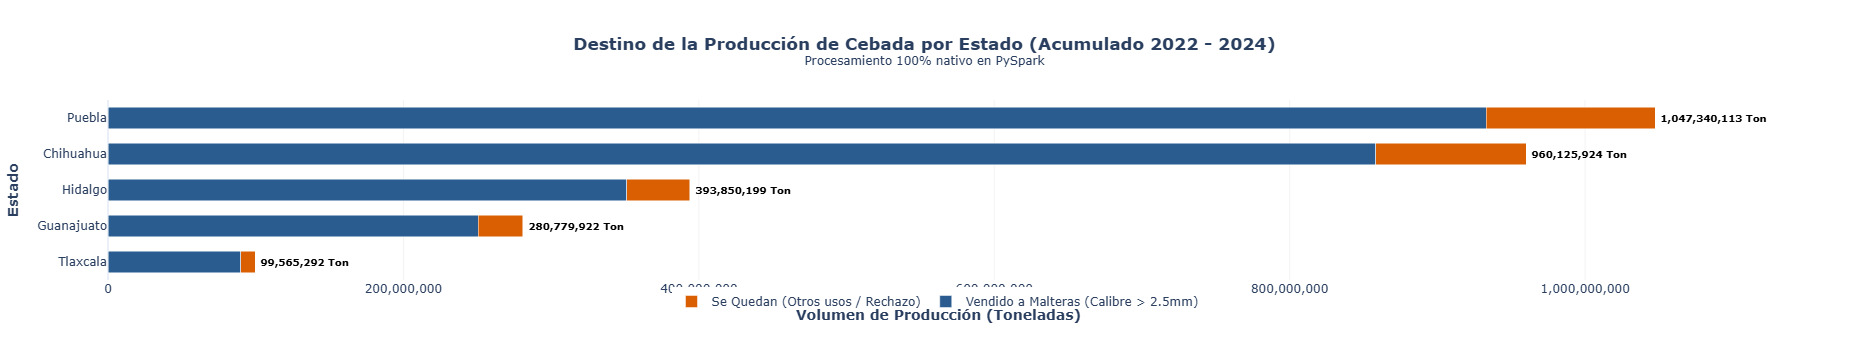

In [20]:
# 1. IMPORTACIONES NATIVAS DE SPARK Y PLOTLY (Sin Pandas)
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import DoubleType
import plotly.graph_objects as go

# Inicializar la sesión de Spark
spark = SparkSession.builder \
    .appName("AnalisisDestinoCebadaSparkPuro") \
    .getOrCreate()

# 2. CARGA EFICIENTE DEL ARCHIVO MASIVO
archivo_csv = 'cebada_base_unida.csv'
df_spark = spark.read.csv(archivo_csv, header=True, encoding='latin1')

# 3. LIMPIEZA Y PROCESAMIENTO DISTRIBUIDO
df_spark = df_spark.withColumn(
    "Produccion_Total_Ton", 
    F.when(F.col("Produccion_Total_Ton").cast(DoubleType()) < 0, 0.0)
     .otherwise(F.coalesce(F.col("Produccion_Total_Ton").cast(DoubleType()), F.lit(0.0)))
).withColumn(
    "Calibre_Original", 
    F.coalesce(F.col("`Calibre_>2.5mm_%`").cast(DoubleType()), F.lit(0.0))
)

# Aplicación de fórmulas aritméticas
df_spark = df_spark.withColumn(
    "Toneladas_Maltera", 
    F.col("Produccion_Total_Ton") * (F.col("Calibre_Original") / 100.0)
).withColumn(
    "Toneladas_Se_Quedan", 
    F.col("Produccion_Total_Ton") - F.col("Toneladas_Maltera")
)

# 4. AGREGACIÓN Y ORDENAMIENTO EN SPARK
# Calculamos las sumas por estado y una columna de Total para poder ordenar la gráfica
resumen_spark = df_spark.groupby("Estado").agg(
    F.sum("Toneladas_Maltera").alias("Toneladas_Maltera"),
    F.sum("Toneladas_Se_Quedan").alias("Toneladas_Se_Quedan")
).withColumn(
    "Total", 
    F.col("Toneladas_Maltera") + F.col("Toneladas_Se_Quedan")
).sort("Total", ascending=True)

# 5. EXTRACCIÓN DE LISTAS NATIVAS DE SPARK PARA LA GRÁFICA
# .collect() trae los resultados resumidos como filas de Spark de forma segura
filas_resumen = resumen_spark.collect()

estados = [row["Estado"] for row in filas_resumen]
ton_maltera = [row["Toneladas_Maltera"] for row in filas_resumen]
ton_se_quedan = [row["Toneladas_Se_Quedan"] for row in filas_resumen]
totales = [row["Total"] for row in filas_resumen]

# 6. CONSTRUCCIÓN DE LA GRÁFICA HORIZONTAL CON PLOTLY
fig = go.Figure()

# Barra azul: Vendido a Malteras
fig.add_trace(go.Bar(
    y=estados,
    x=ton_maltera,
    name='Vendido a Malteras (Calibre > 2.5mm)',
    orientation='h',
    marker=dict(color='#2b5c8f'),
    hovertemplate="Estado: %{y}<br>Maltera: %{x:,.0f} Ton<extra></extra>"
))

# Barra naranja: Se quedan / Rechazo (Apilada a la derecha)
fig.add_trace(go.Bar(
    y=estados,
    x=ton_se_quedan,
    name='Se Quedan (Otros usos / Rechazo)',
    orientation='h',
    marker=dict(color='#d95f02'),
    hovertemplate="Estado: %{y}<br>Rechazo/Otros: %{x:,.0f} Ton<extra></extra>"
))

# 7. MAQUETACIÓN Y TEXTOS DE LOS TOTALES
# Creamos las etiquetas de texto con el total neto para colocarlas al final de cada barra
anotaciones_totales = []
for i, total_val in enumerate(totales):
    if total_val > 0:
        anotaciones_totales.append(dict(
            x=total_val, 
            y=estados[i],
            text=f" <b>{total_val:,.0f} Ton</b>",
            xanchor='left', 
            yanchor='middle',
            showarrow=False,
            font=dict(color='black', size=10)
        ))

fig.update_layout(
    template="plotly_white",
    title="<b>Destino de la Producción de Cebada por Estado (Acumulado 2022 - 2024)</b><br><sup>Procesamiento 100% nativo en PySpark</sup>",
    title_x=0.5,
    barmode='stack', # Esto hace que las barras se apilen una al lado de la otra (left en matplotlib)
    xaxis=dict(
        title="<b>Volumen de Producción (Toneladas)</b>",
        tickformat=",.0f", # Formato de miles con comas
        gridcolor="rgba(0,0,0,0.05)"
    ),
    yaxis=dict(title="<b>Estado</b>"),
    legend=dict(orientation="h", yanchor="bottom", y=-0.2, xanchor="center", x=0.5),
    annotations=anotaciones_totales,
    bargap=0.4,
    height=800
)

fig.show()

In [ ]:
##APRENDIZAJE DE MAQUINA

In [6]:
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler


spark = SparkSession.builder \
    .appName("AprendizajeMaquinaCebadaSpark") \
    .master("local[*]") \
    .getOrCreate()


nombre_archivo = "cebada_base_unida.csv"
ruta_relativa = os.path.join(".", nombre_archivo)

if not os.path.exists(ruta_relativa):
    raise FileNotFoundError(f"No se encontró el archivo '{nombre_archivo}' en la carpeta actual. Verifica la ruta.")


df_spark = spark.read.csv(ruta_relativa, header=True, inferSchema=True)


df_clean = df_spark \
    .withColumn("Precio_Venta_Ton_MXN", F.abs(F.col("Precio_Venta_Ton_MXN").cast(DoubleType()))) \
    .withColumn("Volumenproduccion", F.abs(F.col("Volumenproduccion").cast(DoubleType()))) \
    .withColumn("Humedad_Recepcion_%", F.abs(F.col("Humedad_Recepcion_%").cast(DoubleType()))) \
    .withColumn("Proteina_Total_ss_%", F.abs(F.col("Proteina_Total_ss_%").cast(DoubleType())))


mediana_precio = df_clean.approxQuantile("Precio_Venta_Ton_MXN", [0.5], 0.01)[0]


df_clase = df_clean.withColumn(
    "Precio_Alto",
    F.when(F.col("Precio_Venta_Ton_MXN") > mediana_precio, 1).otherwise(0)
)


columnas_modelo = ["Volumenproduccion", "Humedad_Recepcion_%", "Proteina_Total_ss_%", "Precio_Alto"]
df_filtrado = df_clase.select(columnas_modelo).dropna()




features_cols = ["Volumenproduccion", "Humedad_Recepcion_%", "Proteina_Total_ss_%"]
assembler = VectorAssembler(inputCols=features_cols, outputCol="features")

df_con_features = assembler.transform(df_filtrado)

train_data, test_data = df_con_features.randomSplit([0.7, 0.3], seed=42)


print("\n>>> Procesamiento en PySpark puro completado.")
print(f" -> Registros en el Conjunto de Entrenamiento: {train_data.count()}")
print(f" -> Registros en el Conjunto de Prueba: {test_data.count()}")

train_data.select("features", "Precio_Alto").show(5, truncate=False)


>>> Procesamiento en PySpark puro completado.
 -> Registros en el Conjunto de Entrenamiento: 13860104
 -> Registros en el Conjunto de Prueba: 5943438
+-------------------------+-----------+
|features                 |Precio_Alto|
+-------------------------+-----------+
|[54.0528,13.9649,10.2719]|0          |
|[54.0528,13.9649,10.2719]|0          |
|[54.0528,13.9649,10.2719]|0          |
|[54.0528,13.9649,10.2719]|0          |
|[54.0528,13.9649,10.2719]|0          |
+-------------------------+-----------+
only showing top 5 rows



--- INFORME DE RENDIMIENTO: REGRESIÓN LOGÍSTICA (SPARK) ---
                 precision    recall  f1-score   support

Precio Bajo (0)       0.54      0.51      0.53   2961012
Precio Alto (1)       0.54      0.57      0.56   2982426

       accuracy                           0.54   5943438
      macro avg       0.54      0.54      0.54   5943438
   weighted avg       0.54      0.54      0.54   5943438



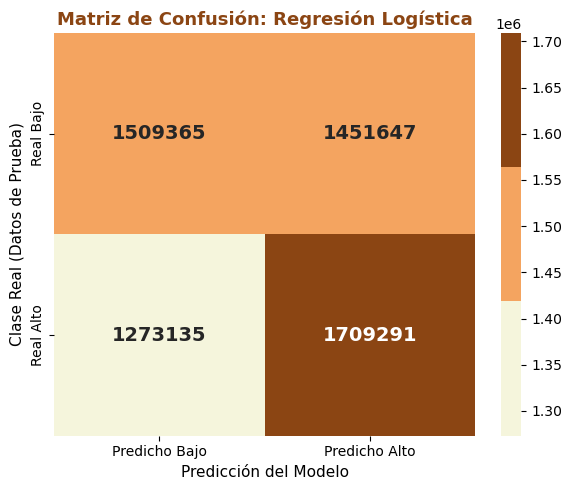

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol="features", labelCol="Precio_Alto")
modelo_logistico_spark = lr.fit(train_data)

predicciones = modelo_logistico_spark.transform(test_data)

y_true = [int(row['Precio_Alto']) for row in predicciones.select("Precio_Alto").collect()]
y_pred = [int(row['prediction']) for row in predicciones.select("prediction").collect()]

print("--- INFORME DE RENDIMIENTO: REGRESIÓN LOGÍSTICA (SPARK) ---")
print(classification_report(y_true, y_pred, target_names=["Precio Bajo (0)", "Precio Alto (1)"]))

matriz = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))

cmap_personalizado = sns.color_palette(["#F5F5DC", "#F4A460", "#8B4513"], as_cmap=True)

sns.heatmap(matriz, annot=True, fmt='d', cmap=cmap_personalizado, cbar=True,
            xticklabels=["Predicho Bajo", "Predicho Alto"],
            yticklabels=["Real Bajo", "Real Alto"],
            annot_kws={"size": 14, "fontweight": "bold"})

plt.title('Matriz de Confusión: Regresión Logística', fontsize=13, fontweight='bold', color='#8B4513')
plt.xlabel('Predicción del Modelo', fontsize=11)
plt.ylabel('Clase Real (Datos de Prueba)', fontsize=11)
plt.tight_layout()
plt.show()



En Spark ML, para variables categoricas u objetivos binarios como 'Precio_Alto',
el algoritmo mide la impureza utilizando el criterio de Gini o Entropía por defecto.
Busca la variable (Volumen, Humedad o Proteína) que maximice la 'Ganancia de Información'
al dividir los datos, logrando que los nodos hijos sean lo más puros posibles.

--- ESTRUCTURA LOGICA DEL ARBOL EN SPARK ---
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_e5a6eaf7f777, depth=3, numNodes=15, numClasses=2, numFeatures=3
  If (Humedad_Recepcion_% <= 13.96705)
   If (Proteina_Total_ss_% <= 9.289850000000001)
    If (Volumenproduccion <= 1198.10995)
     Predict: 1.0
    Else (Volumenproduccion > 1198.10995)
     Predict: 0.0
   Else (Proteina_Total_ss_% > 9.289850000000001)
    If (Proteina_Total_ss_% <= 9.46345)
     Predict: 1.0
    Else (Proteina_Total_ss_% > 9.46345)
     Predict: 0.0
  Else (Humedad_Recepcion_% > 13.96705)
   If (Volumenproduccion <= 8044.07575)
    If (Proteina_Total_ss_% <= 8.6966)
  

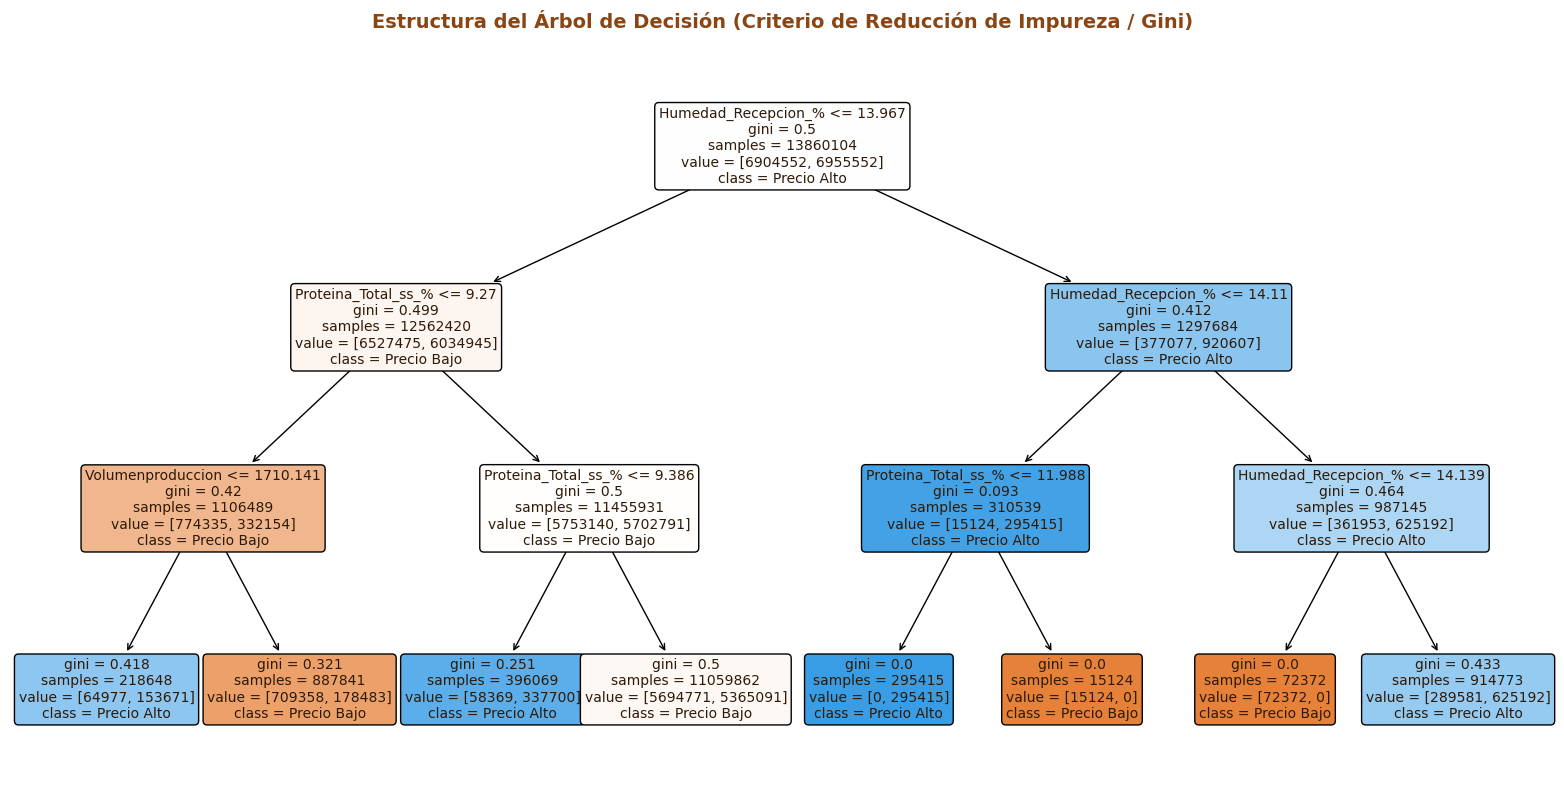


>>> ¡Árbol generado con éxito!


In [8]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier as SklearnDecisionTree, plot_tree
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(featuresCol="features", labelCol="Precio_Alto", maxDepth=3, seed=42)
modelo_arbol_spark = dt.fit(train_data)


predicciones_arbol = modelo_arbol_spark.transform(test_data)



print("En Spark ML, para variables categoricas u objetivos binarios como 'Precio_Alto',")
print("el algoritmo mide la impureza utilizando el criterio de Gini o Entropía por defecto.")
print("Busca la variable (Volumen, Humedad o Proteína) que maximice la 'Ganancia de Información'")
print("al dividir los datos, logrando que los nodos hijos sean lo más puros posibles.\n")


print("--- ESTRUCTURA LOGICA DEL ARBOL EN SPARK ---")
lineas_arbol = modelo_arbol_spark.toDebugString

nombres_features = ["Volumenproduccion", "Humedad_Recepcion_%", "Proteina_Total_ss_%"]
arbol_legible = lineas_arbol
for i, nombre in enumerate(nombres_features):
    arbol_legible = arbol_legible.replace(f"feature {i}", nombre)

print(arbol_legible)



df_muestra = train_data.select("Volumenproduccion", "Humedad_Recepcion_%", "Proteina_Total_ss_%", "Precio_Alto").dropna().toPandas()

X_sample = df_muestra[["Volumenproduccion", "Humedad_Recepcion_%", "Proteina_Total_ss_%"]]
y_sample = df_muestra["Precio_Alto"]

arbol_visual = SklearnDecisionTree(max_depth=3, random_state=42)
arbol_visual.fit(X_sample, y_sample)

plt.figure(figsize=(16, 8))
plot_tree(arbol_visual,
          feature_names=nombres_features,
          class_names=["Precio Bajo", "Precio Alto"],
          filled=True,
          rounded=True,
          fontsize=10)

for patch in plt.gca().get_children():
    if isinstance(patch, plt.Text):
        patch.set_color('#2E1A08')

plt.title('Estructura del Árbol de Decisión (Criterio de Reducción de Impureza / Gini)', fontsize=14, fontweight='bold', color='#8B4513', pad=20)
plt.tight_layout()
plt.show()

print("\n>>> ¡Árbol generado con éxito!")

In [9]:
#ERE
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

# 1. INICIALIZACIÓN SPARK
spark = SparkSession.builder.appName("LogisticaSpark").getOrCreate()
# Asegúrate de que tu archivo esté en la ruta correcta
df_spark = spark.read.csv("cebada_base_unida.csv", header=True, inferSchema=True)

df_clean = df_spark.filter(F.col("pob_latitud").isNotNull() & F.col("pob_longitud").isNotNull()) \
                  .withColumn("Estado", F.upper(F.trim(F.col("Estado")))) \
                  .withColumn("pob_municipio", F.upper(F.trim(F.col("pob_municipio")))) \
                  .filter(F.upper(F.col("Estatus")) == "ACTIVO").cache()

# 2. FUNCIONES MATEMÁTICAS
def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

# 3. INTERFAZ
dropdown_edo = widgets.Dropdown(options=[row[0] for row in df_clean.select("Estado").distinct().orderBy("Estado").collect()], description='Estado:')
selector_munis = widgets.SelectMultiple(options=[], description='Seleccionar:', layout={'width': '70%', 'height': '150px'})
dropdown_origen = widgets.Dropdown(options=[], description='Inicio:')
dropdown_destino = widgets.Dropdown(options=[], description='Final:')
btn_calcular = widgets.Button(description='Calcular Ruta', button_style='success')
output_panel = widgets.Output()

def actualizar_lista(*args):
    munis = df_clean.filter(F.col("Estado") == dropdown_edo.value).select("pob_municipio").distinct().orderBy("pob_municipio").collect()
    lista_munis = [m[0] for m in munis]
    selector_munis.options = lista_munis
    dropdown_origen.options = lista_munis
    dropdown_destino.options = lista_munis

dropdown_edo.observe(actualizar_lista, 'value')
actualizar_lista()

# 4. LÓGICA DE CÁLCULO
def ejecutar_logistica(b):
    with output_panel:
        clear_output()
        seleccionados = list(selector_munis.value)
        origen = dropdown_origen.value
        destino = dropdown_destino.value
        
        if origen not in seleccionados or destino not in seleccionados or len(seleccionados) < 2:
            print("Error: El municipio de inicio y final deben estar en la selección.")
            return
        
        # Obtener coordenadas
        df_coords = df_clean.filter(F.col("Estado") == dropdown_edo.value).select("pob_municipio", "pob_longitud", "pob_latitud").distinct().toPandas()
        coord_dict = {row['pob_municipio']: (row['pob_longitud'], row['pob_latitud']) for _, row in df_coords.iterrows()}
        
        # Ruta Tradicional (orden de selección)
        dist_tradicional = sum(haversine_np(*coord_dict[seleccionados[i]], *coord_dict[seleccionados[i+1]]) for i in range(len(seleccionados)-1))
        
        # Ruta Optimizada (Nearest Neighbor)
        ruta_opt = [origen]
        pendientes = [m for m in seleccionados if m != origen and m != destino]
        while pendientes:
            dists = [haversine_np(coord_dict[ruta_opt[-1]][0], coord_dict[ruta_opt[-1]][1], coord_dict[p][0], coord_dict[p][1]) for p in pendientes]
            idx = np.argmin(dists)
            ruta_opt.append(pendientes[idx])
            pendientes.pop(idx)
        ruta_opt.append(destino)
        
        dist_optimizada = sum(haversine_np(*coord_dict[ruta_opt[i]], *coord_dict[ruta_opt[i+1]]) for i in range(len(ruta_opt)-1))
        ahorro = dist_tradicional - dist_optimizada

        # Mostrar Tabla
        display(HTML(f"<h3>Resultado: Ruta de {origen} a {destino}</h3>"))
        display(HTML(f"""<table style="width:100%; border: 1px solid black;">
            <tr><th>Estrategia</th><th>Distancia</th></tr>
            <tr><td>Tradicional</td><td>{dist_tradicional:.2f} Km</td></tr>
            <tr style="background-color: #d4edda;"><td><b>Optimizada</b></td><td><b>{dist_optimizada:.2f} Km</b></td></tr>
            <tr><td><b>Ahorro</b></td><td><b>{ahorro:.2f} Km ({(ahorro/dist_tradicional)*100:.1f}%)</b></td></tr>
        </table>"""))
        print(f"\nOrden de visita sugerido: {' → '.join(ruta_opt)}")

        # Graficar
        plt.figure(figsize=(12, 8))
        pos = {m: coord_dict[m] for m in coord_dict}
        
        # Fondo: Todos los municipios del estado
        nx.draw_networkx_nodes(nx.Graph(), pos, nodelist=coord_dict.keys(), node_size=20, node_color='#E5E7E9')
        nx.draw_networkx_labels(nx.Graph(), pos, labels={m: m for m in coord_dict.keys()}, font_size=6, font_color='gray')
        
        # Ruta: Seleccionados
        G_ruta = nx.DiGraph()
        aristas = [(ruta_opt[i], ruta_opt[i+1]) for i in range(len(ruta_opt)-1)]
        G_ruta.add_edges_from(aristas)
        nx.draw_networkx_nodes(G_ruta, pos, node_size=300, node_color='#2ECC71')
        nx.draw_networkx_edges(G_ruta, pos, edgelist=aristas, edge_color='#27AE60', width=2, arrowsize=20)
        nx.draw_networkx_labels(G_ruta, pos, font_size=8, font_weight='bold')
        
        plt.title("Visualización de Ruta Optimizada")
        plt.axis('off')
        plt.show()

btn_calcular.on_click(ejecutar_logistica)
display(widgets.VBox([dropdown_edo, selector_munis, dropdown_origen, dropdown_destino, btn_calcular, output_panel]))